# LIBRARIES

In [2]:
import sys
import importlib
import re

import torch
import numpy as np
import pandas as pd

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.animation as animation

sys.path.append('../Scripts/')


# from train import train

import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

# DATA LOAD

In [3]:
df = pd.read_csv('../Data/dataSet_electrolizador_15d.csv')

# Select only cell 16
df = df[['datetime', 'PLL:.19RA_CS016VWJ1.AInput1.St.PV','PLL:.19RA_TIT200P.AInput1.St.PV','PLL:.ConsumoEliz.PV',
         'PLL:.19RA_PIT300P.AInput1.St.PV',]]
# Rename columns [datetime, V,T,Consumo,p]
df.columns = ['datetime', 'V', 'T', 'Consumo', 'p']
# Drop column p
df = df.drop(columns=['p'])
# Divide df['Consumo'] by 10 to get the power of one stack
df['Consumo'] = df['Consumo']/10
df['T'] = df['T'] + 273.15 # Kelvin
df['Consumo'] = df['Consumo']*1e6/200 # W
df['V'] = df['V']/200 # V # Assuming 200 cells in series

# Convert to datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df['time_seconds'] = (df['datetime'] - df['datetime'][0]).dt.total_seconds()
df['time_hours'] = df['time_seconds']/3600

# Filter values with temp greater than 300 and voltage greater than 2
# df = df[(df['T'] > 300) & (df['V'] < 2)]
df = df[(df['T'] > 300) & (df['V'] > 2)]

# Take values lower than august 28 (2 stacks stop working)
df = df[df['datetime'] < '2024-08-28']

# Print number of days available
print('Number of days available:', (df['datetime'].iloc[-1] - df['datetime'].iloc[0]).days)

df.head()

Number of days available: 12


,datetime,V,T,Consumo,time_seconds,time_hours
10,2024-08-15 00:10:00+02:00,2.008647,331.470114,6279.14145,600.0,0.166667
12,2024-08-15 00:12:00+02:00,2.025133,333.714693,6334.18560,720.0,0.200000
13,2024-08-15 00:13:00+02:00,2.021177,332.531676,6332.09275,780.0,0.216667
14,2024-08-15 00:14:00+02:00,2.038448,332.315783,6394.56320,840.0,0.233333
15,2024-08-15 00:15:00+02:00,2.035834,330.772646,6380.58235,900.0,0.250000


In [4]:
from plotly.subplots import make_subplots

# Create subplots with shared x-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(go.Scatter(x=df['datetime'], y=df['V'], mode='lines', name='V'), secondary_y=False)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['T'], mode='lines', name='T'), secondary_y=True)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['Consumo'], mode='lines', name='Consumo', yaxis='y3'))
# Create axis objects
fig.update_layout(
    yaxis3=dict(title='p', side='right', overlaying='y', anchor='free')
)

# Set axis titles
fig.update_xaxes(title_text="Datetime")
fig.update_yaxes(title_text="V / Consumo", secondary_y=False)
fig.update_yaxes(title_text="T / p", secondary_y=True)

# Show plot
fig.show()

In [5]:
# df = pd.read_csv('../Data/dataSet_electrolizador_15d.csv')
# ## Filter dataset to obtain one period of continuos data [18/08/2024 00:00:00 - 18/08/2024 23:59:59]
# df = df[(df['datetime'] >= '2024-08-17 00:00:00') & (df['datetime'] <= '2024-08-19 23:59:59')]

# # Filter by datetime so the column 'PLL:.19RA_CS016VWJ1.AInput1.St.PV' is greater than 300
# df = df[df["PLL:.19RA_CS016VWJ1.AInput1.St.PV"] > 400]

# # Select only cell 16
# df = df[['datetime', 'PLL:.19RA_CS016VWJ1.AInput1.St.PV','PLL:.19RA_TIT200P.AInput1.St.PV','PLL:.ConsumoEliz.PV',
#          'PLL:.19RA_PIT300P.AInput1.St.PV',]]
# # Rename columns [datetime, V,T,Consumo,p]
# df.columns = ['datetime', 'V', 'T', 'Consumo', 'p']
# # Drop column p
# df = df.drop(columns=['p'])
# # Divide df['Consumo'] by 10 to get the power of one stack
# df['Consumo'] = df['Consumo']/10


# df['T'] = df['T'] + 273.15 # Kelvin
# df['Consumo'] = df['Consumo']*1e6/200 # W
# df['V'] = df['V']/200 # V # Assuming 200 cells in series

# df.head()

## DATA VISUALIZATION

In [6]:
from plotly.subplots import make_subplots

# Create subplots with shared x-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(go.Scatter(x=df['datetime'], y=df['V'], mode='lines', name='V'), secondary_y=False)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['T'], mode='lines', name='T'), secondary_y=True)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['Consumo'], mode='lines', name='Consumo', yaxis='y3'))
# Create axis objects
fig.update_layout(
    yaxis3=dict(title='p', side='right', overlaying='y', anchor='free')
)

# Set axis titles
fig.update_xaxes(title_text="Datetime")
fig.update_yaxes(title_text="V / Consumo", secondary_y=False)
fig.update_yaxes(title_text="T / p", secondary_y=True)

# Show plot
fig.show()

# DATA PREPROCESSING

In [7]:
# Import necessary libraries
import math
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

# Part 1: Function to compute V given P, assuming k2 = 0
def generateVoltage(P, k1, k3):
    """Computes V given P assuming k2 = 0."""
    # Ensure k1 and k3 are valid
    if k3 == 0:
        raise ValueError("k3 cannot be zero.")
    if torch.any(P < 0):  # Ensure P is non-negative (for tensor input)
        raise ValueError("P must be non-negative.")
    
    # Calculate V using the quadratic formula for each element in P
    discriminant = k1**2 + 4 * k3 * P
    V = (k1 + torch.sqrt(discriminant)) / 2
    return V

# Part 2: Infer k1, k2, and k3 using PyTorch
def infer_constants(P_values, V_values,a_cell, k1=None, k2=None, k3=None, learning_rate=0.1, epochs=5000):
    """
    Infer k1, k2, k3 from a dataset of P and V values using PyTorch.
    If k1, k2, or k3 are not provided (None), they will be inferred.
    """
    # If any of k1, k2, k3 is None, initialize them as trainable parameters

    optim_vars = []

    if k1 is None:
        k1 = torch.randn(1, requires_grad=True, dtype=torch.float32)
        optim_vars.append(k1)
    else:
        k1 = torch.tensor(k1, dtype=torch.float32, requires_grad=True)

    if k2 is None:
        k2 = torch.randn(1, requires_grad=True, dtype=torch.float32)
        optim_vars.append(k2)
    else:
        k2 = torch.tensor(k2, dtype=torch.float32, requires_grad=True)

    if k3 is None:
        k3 = torch.randn(1, requires_grad=True, dtype=torch.float32)
        optim_vars.append(k3)
    else:
        k3 = torch.tensor(k3, dtype=torch.float32, requires_grad=True)

    # Voltage equation is given by
    # V_cell = k1 + k2*torch.log(P/(a_cell*V_cell)) + k3*(1/lm)*P/(a_cell*V_cell)
    
    # Ensure P_values and V_values are tensors
    P = P_values/a_cell
    V_actual = V_values

    # Define optimizer
    # optimizer = optim.Adam([k1, k2, k3], lr=learning_rate)
    optimizer = optim.Adam(optim_vars, lr=learning_rate)

    # Define loss function (mean squared error)
    loss_fn = nn.MSELoss()

    # Training loop
    for epoch in range(epochs):
        # Compute predicted V values using the model
        V_pred = k1 + k2 * torch.log(P / V_actual) + k3 * (P / V_actual)
        
        # Compute loss
        loss = loss_fn(V_pred, V_actual)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Optionally print progress every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.6f}, k1: {k1.item():.6f}, k2: {k2.item():.6f}, k3: {k3.item():.6f}")

    # Return the inferred or provided values of k1, k2, k3
    return k1.item(), k2.item(), k3.item(), V_pred

# k1 = 2.0
# k3 = 5.0

# # Part 2: Infer k1, k2, k3 from a dataset (using tensors)
# # Create a synthetic dataset of (P, V) pairs (now using tensors directly)
# P_values = torch.tensor([i for i in range(1, 20)], dtype=torch.float32)  # Example P values
# V_values = generateVoltage(P_values, k1, k3)  # Generate corresponding V values using tensors

# # Infer k1, k2, and k3
# inferred_k1, inferred_k2, inferred_k3, V_pred = infer_constants(P_values, V_values,k1=2.0)
# print(f"Inferred constants: k1={inferred_k1:.4f}, k2={inferred_k2:.4f}, k3={inferred_k3:.4f}")


In [8]:

T = torch.tensor(df['T'].values) # Heat (Kelvin)
P = torch.tensor(df['Consumo'].values) # Transfer to W
V = torch.tensor(df['V'].values) # Voltages

from plotly.subplots import make_subplots

# Create subplots with shared x-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(go.Scatter(x=df['datetime'], y=df['V'], mode='lines', name='V'), secondary_y=False)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['T'], mode='lines', name='T'), secondary_y=True)
fig.add_trace(go.Scatter(x=df['datetime'], y=df['Consumo'], mode='lines', name='Consumo', yaxis='y3'))
# Create axis objects
fig.update_layout(
    yaxis3=dict(title='p', side='right', overlaying='y', anchor='free')
)

# Set axis titles
fig.update_xaxes(title_text="Datetime")
fig.update_yaxes(title_text="V / Consumo", secondary_y=False)
fig.update_yaxes(title_text="T / p", secondary_y=True)

# Show plot
fig.show()

In [9]:
torch.manual_seed(42)

# Universal Gas Constant R = 8.314 J/(mol K)
R = 8.314
# Faraday Constant F = 96485 C/mol
F = 96485.33212
# alpha = 0.5
alpha = 0.5

k2 = (R*T)/(2*alpha*F)
k2 = k2.mean().item()
print(k2)
a_cell = 680*1e-4 #m^2


# G_H2O  = -237.14 'kJ/mol' 
G_H2O = -237.14*1e3 # Convert to Joules
# alpha = 0.5
alpha = 0.5
i_0 = 1e-5 # 'A/cm^2'
# Convert i_0 to A/m^2
i_0 = i_0 * 1e4
a_H2 = 30
a_O2 = 0.5

# k1 = G_H2O/(-2*F) + (R*T)/(2*F)*(np.log(a_H2*(a_O2**0.5))) - (R*T)/(2*alpha*F)*(np.log(a_cell*i_0))
k1 = G_H2O/(-2*F) - ((R*T)/(2*alpha*F))*(np.log(a_cell*i_0)) + ((R*T)/(2*F))*(np.log(a_H2*(a_O2**0.5)))
k1 = k1.mean().item()
print(k1)


# Infer k1, and k3
inferred_k1, inferred_k2, inferred_k3, V_pred = infer_constants(P,V,a_cell,epochs=1000,k1=k1,k2=k2)
print(f"Inferred constants: k1={inferred_k1:.4f}, k2={inferred_k2:.4f}, k3={inferred_k3:.4f}")

0.028546209074438517
1.4149597706434516
Epoch 0, Loss: 240645412.870487, k1: 1.414960, k2: 0.028546, k3: 0.236690
Epoch 100, Loss: 1411.258343, k1: 1.414960, k2: 0.028546, k3: -0.000222
Epoch 200, Loss: 0.148190, k1: 1.414960, k2: 0.028546, k3: 0.000013
Epoch 300, Loss: 0.000021, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 400, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 500, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 600, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 700, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 800, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Epoch 900, Loss: 0.000018, k1: 1.414960, k2: 0.028546, k3: 0.000007
Inferred constants: k1=1.4150, k2=0.0285, k3=0.0000


In [10]:
# Universal Gas Constant R = 8.314 J/(mol K)
R = 8.314
# Faraday Constant F = 96485 C/mol
F = 96485.33212

sigma_30 = 6.5 # 1/Ohm*m
sigma_mem = sigma_30 * torch.exp(1268*(1/(torch.ones_like(T)*303.15) - 1/T))
sigma_mem = sigma_mem.mean()
print(sigma_mem)

t_mem = inferred_k3*(sigma_mem)*1e2 # Convert to cm
t_mem

tensor(9.2721, dtype=torch.float64)


tensor(0.0063, dtype=torch.float64)

In [11]:
#Generate data (Using the inferred constant)
#  V_cell = k1 + k2*torch.log(P/V_cell) + k3*(1/lm)*P/V_cell
P_area = P/a_cell
V_cell_check = inferred_k1 + inferred_k2*torch.log(P_area/V) + (t_mem/(1e2*sigma_mem))*P_area/V

# Comput the error with the actual V
error = torch.abs(V - V_cell_check)
mse = torch.mean(error**2)
mse


tensor(1.7533e-05, dtype=torch.float64)

# PINN TRAINING

## PARAMETER INFERENCE

In [20]:
# Neural Network Model
class PINN(nn.Module):
    def __init__(self, t0, y01, y02):
        super(PINN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        self.output2 = nn.Linear(32, 1)  # Second output
        
        self.t0 = t0
        self.y01 = y01
        self.y02 = y02

        # Define k as a learnable parameter
        self.k = nn.Parameter(torch.tensor(0.1, dtype=torch.float32))

    def forward(self, x):
        features = self.hidden(x)
        y1 = torch.exp(self.output1(features))
        y2 = torch.exp(self.output2(features))
        return y1, y2
    
    def physics_loss(self, t_phys, x_phys, ode_residual_f_func, ode_residual_g_func, lambda_phys_f, lambda_phys_g):
        t_phys.requires_grad = True
        y1, y2 = self.forward(t_phys)
        f_pred, g_pred = y1, y2

        df_dx = torch.autograd.grad(f_pred, t_phys, torch.ones_like(f_pred), create_graph=True)[0]
        dg_dx = torch.autograd.grad(g_pred, t_phys, torch.ones_like(g_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(f_pred, g_pred, df_dx, dg_dx, t_phys, x_phys)
        ode_residual_g = ode_residual_g_func(g_pred,dg_dx, t_phys, self.k)
        
        return lambda_phys_f * torch.mean(ode_residual_f**2) + lambda_phys_g * torch.mean(ode_residual_g**2)
    
    def mse_loss(self, t_data, f_data, g_data, lambda_mse_f, lambda_mse_g):
        f_pred, g_pred = self.forward(t_data)
        loss_f = nn.MSELoss()(f_pred, f_data)
        loss_g = nn.MSELoss()(g_pred, g_data)
        return lambda_mse_f * loss_f + lambda_mse_g * loss_g

# Training function
def train(model, t_mse, t_phys, x_phys, y1_train, y2_train, ode_residual_f_func, ode_residual_g_func, epochs=1000, lr=0.01,
          lambda_mse=1.0, lambda_phys=1.0, lambda_phys_f=1.0, lambda_phys_g=1.0, lambda_mse_f=1.0, lambda_mse_g=1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss_mse = model.mse_loss(t_mse, y1_train, y2_train, lambda_mse_f=lambda_mse_f, lambda_mse_g=lambda_mse_g)
        physics_loss = model.physics_loss(t_phys, x_phys, ode_residual_f_func, ode_residual_g_func, 
                                          lambda_phys_f=lambda_phys_f, lambda_phys_g=lambda_phys_g)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}, k = {model.k.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, t_test, t_train_mse, f_train, g_train, f_test, g_test, f_func=None, g_func=None,figsize=(12, 6)):
    model.eval()
    with torch.no_grad():
        y1_pred, y2_pred = model(t_test)
    
    t_test_np = t_test.detach().numpy()
    t_train_mse_np = t_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    y2_pred_np = y2_pred.detach().numpy()
    
    plt.figure(figsize=figsize)

    # Subplot for f(x)
    plt.subplot(1, 2, 1)
    if f_func:
        plt.scatter(t_test_np, f_func(t_test_np), label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_func(t_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, f_test, label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_train, label="Training f(x)", marker='o', s=30, edgecolor='k')
    # Set y-axis limits as +- 10% of the max/min values
    
    plt.legend()
    plt.title("True vs Predicted f(x)")

    # Subplot for g(x)
    plt.subplot(1, 2, 2)
    if g_func:
        plt.scatter(t_test_np, g_func(t_test_np), label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_func(t_train_mse_np), label="Training g(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, g_test, label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_train, label="Training g(x)", marker='o', s=30, edgecolor='k')
    plt.ylim(0.63, 0.64)
    plt.legend()
    plt.title("True vs Predicted g(x)")

    plt.tight_layout()
    plt.show()



In [21]:
df.head()

,datetime,V,T,Consumo,time_seconds,time_hours
10,2024-08-15 00:10:00+02:00,2.008647,331.470114,6279.14145,600.0,0.166667
12,2024-08-15 00:12:00+02:00,2.025133,333.714693,6334.18560,720.0,0.200000
13,2024-08-15 00:13:00+02:00,2.021177,332.531676,6332.09275,780.0,0.216667
14,2024-08-15 00:14:00+02:00,2.038448,332.315783,6394.56320,840.0,0.233333
15,2024-08-15 00:15:00+02:00,2.035834,330.772646,6380.58235,900.0,0.250000


------------------------------- QUADRATIC DECREASE ------------------------
Epoch 0: Total Loss = 2.360708, MSE Loss = 2.357029, Physics Loss = 0.003679, k = 0.090000
Epoch 100: Total Loss = 0.000065, MSE Loss = 0.000063, Physics Loss = 0.000002, k = 0.000331
Epoch 200: Total Loss = 0.000028, MSE Loss = 0.000027, Physics Loss = 0.000001, k = 0.000007
Epoch 300: Total Loss = 0.000027, MSE Loss = 0.000026, Physics Loss = 0.000001, k = 0.000005
Epoch 400: Total Loss = 0.000027, MSE Loss = 0.000026, Physics Loss = 0.000001, k = 0.000003
Epoch 500: Total Loss = 0.000026, MSE Loss = 0.000025, Physics Loss = 0.000001, k = 0.000002
Epoch 600: Total Loss = 0.000026, MSE Loss = 0.000025, Physics Loss = 0.000001, k = 0.000002
Epoch 700: Total Loss = 0.000026, MSE Loss = 0.000025, Physics Loss = 0.000001, k = 0.000001
Epoch 800: Total Loss = 0.000026, MSE Loss = 0.000025, Physics Loss = 0.000001, k = 0.000001
Epoch 900: Total Loss = 0.000026, MSE Loss = 0.000025, Physics Loss = 0.000001, k = 0.000

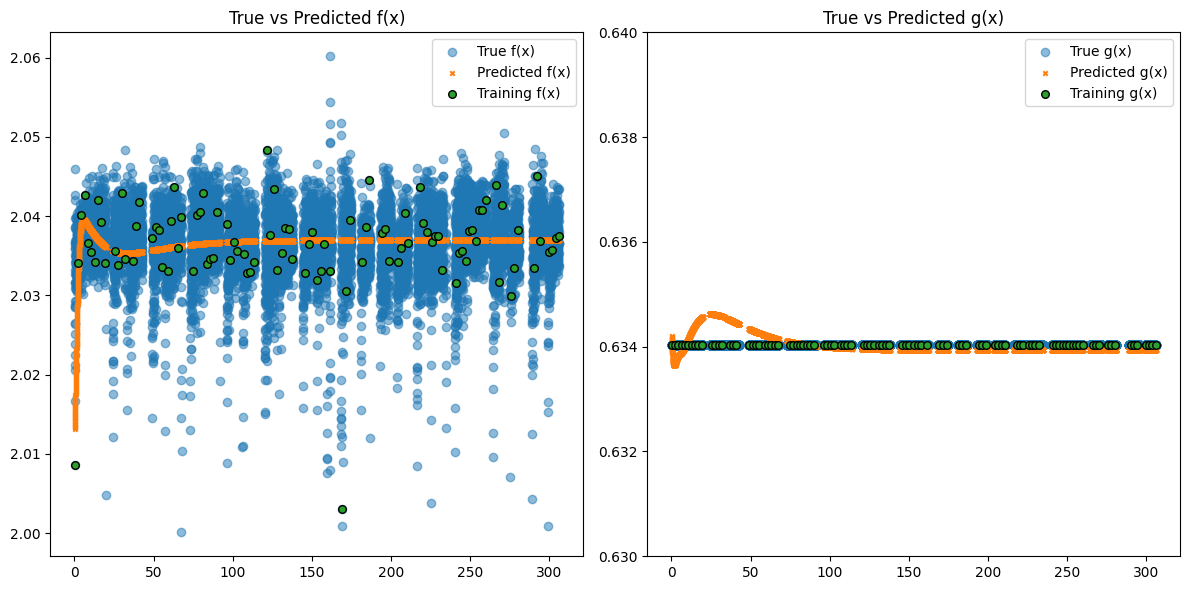

Inferred k: 8.660614412292489e-07


In [22]:
### VOLTAGE TRAINING
torch.manual_seed(0)

## Print at the beginning that this is the quadratic case
print('------------------------------- QUADRATIC DECREASE ------------------------')

ini = 0.5
fin = 1.5
factor = 1e2
Area_cell = 680
initial_thickness = 0.63e-2
t_phys = torch.tensor(df['time_hours'].values, dtype=torch.float32).reshape(-1, 1)
x_phys = torch.tensor(df['V'].values, dtype=torch.float32).reshape(-1, 1)
P_area = torch.tensor(df['Consumo'].values/Area_cell, dtype=torch.float32).reshape(-1, 1)
f_values = torch.tensor(df['V'].values, dtype=torch.float32).reshape(-1, 1)
# t_phys = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
# P_area = torch.tensor(df['P'].values/Area_cell, dtype=torch.float32).reshape(-1, 1)
# k = k4_mean_torch


ode_residual_f_func = lambda f_predd, g_predd, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-inferred_k2 * df_dx/f_predd + inferred_k3 * factor * P_area*(-(dg_dx/(f_predd*g_predd**2))-((df_dx)/(g_predd*f_predd**2))))


# g_func = lambda t, k: 1.78e-2*factor - k*t**2
# ode_residual_g_func = lambda dg_dx, t_phys, k: dg_dx - (-2*k*t_phys)
# g_func = lambda t: initial_thickness * factor * torch.exp(-k * t)
ode_residual_g_func = lambda g_predd,dg_dx, t_phys,k: dg_dx -(-k * g_predd)

# t_train_mse = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
# x_train_mse = i_cell.reshape(-1,1)
t_train_mse = t_phys
x_train_mse = f_values.reshape(-1,1)
# y2_train = g_func(t_train_mse, k4_mean_torch)
# y1_train = f_func(x_train_mse,y2_train)
y2_train = factor*torch.ones_like(t_train_mse)*(t_mem)
y1_train = torch.tensor(df['V'].values, dtype=torch.float32).reshape(-1, 1)
 

# Select 10 equally spaced points in the first half of the data
n = 100
half_index = len(t_train_mse)
indices = torch.linspace(0, half_index - 1, n).long()
t_train_mse, x_train_mse, y1_train, y2_train = t_train_mse[indices], x_train_mse[indices], y1_train[indices], y2_train[indices]



model = PINN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys,x_phys =x_phys,  y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,lr=0.01,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)

# g_test = g_func(t_phys, model.k.item()).detach().numpy()
# f_test = f_func(x_phys,g_func(t_phys,model.k.item())).detach().numpy()
g_test = factor*torch.ones_like(t_phys)*(t_mem)
f_test = df['V'].values

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)

#Print the inferred k 
print('Inferred k:', model.k.item())
